# ZOMBI2 — v1 demo & test notebook

ZOMBI2 simulates **species trees backward in time** (reconstructed birth–death,
conditioned on the number of extant species) and **gene families forward in time**
(duplication / transfer / loss / origination) along that fixed tree.

This notebook exercises the v1 core end-to-end and doubles as a test: several cells
contain `assert`s, so if anything is wrong the notebook fails to execute.

In [1]:
import sys, pathlib

# make the zombi2 package importable whether we run from the repo root or examples/
for cand in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (cand / "zombi2" / "__init__.py").exists():
        sys.path.insert(0, str(cand))
        break

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import zombi2 as z
print("zombi2", z.__version__)
print("numpy ", np.__version__)

zombi2 0.1.0.dev0
numpy  2.4.0


## 1. Simulate a species tree (backward)

We condition on `N` extant tips and a crown age. The root sits at time 0 and all extant leaves at `age`.

In [2]:
sp = z.SpeciesTreeModel(birth=1.0, death=0.3, n_tips=12, age=5.0, age_type="crown")
tree = z.simulate_species_tree(sp, np.random.default_rng(7))

print("leaves          :", len(tree.leaves()))
print("internal nodes  :", len(tree.internal_nodes()))
print("root time       :", tree.root.time)
print("total age       :", tree.total_age)
print("ultrametric     :", all(abs(l.time - tree.total_age) < 1e-9 for l in tree.leaves()))
print()
print(tree.to_newick())

assert len(tree.leaves()) == sp.n_tips
assert len(tree.internal_nodes()) == sp.n_tips - 1

leaves          : 12
internal nodes  : 11
root time       : 0.0
total age       : 5.0
ultrametric     : True

((((((n10:0.2579572306,n3:0.2579572306)i5:1.40647119,(n6:1.061959681,(n8:0.6637358193,n11:0.6637358193)i7:0.3982238614)i6:0.6024687396)i4:0.1181889904,n2:1.782617411)i3:0.1491852546,n1:1.931802665)i2:0.402642028,(n7:0.3650687257,(n4:0.005170311457,n9:0.005170311457)i9:0.3598984142)i8:1.969375968)i1:2.665555307,(n12:2.569440082,n5:2.569440082)i10:2.430559918)root;


### Draw it
A simple time-calibrated cladogram (x-axis = time, root at 0).

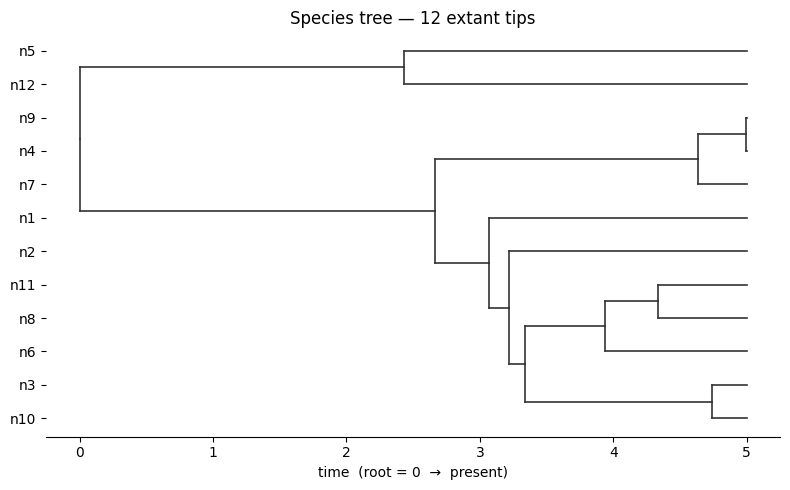

In [3]:
def plot_tree(tree, ax):
    # leaf order via a pre-order traversal
    order = [n for n in tree.nodes_preorder() if n.is_leaf()]
    y = {leaf: i for i, leaf in enumerate(order)}

    def yof(node):
        if node.is_leaf():
            return y[node]
        y[node] = float(np.mean([yof(c) for c in node.children]))
        return y[node]
    yof(tree.root)

    def draw(node):
        for c in node.children:
            ax.plot([node.time, node.time], [y[node], y[c]], color="0.2", lw=1.2)
            ax.plot([node.time, c.time], [y[c], y[c]], color="0.2", lw=1.2)
            draw(c)
    draw(tree.root)
    ax.set_yticks([y[l] for l in order])
    ax.set_yticklabels([l.name for l in order])
    ax.set_xlabel("time  (root = 0  →  present)")
    ax.set_title(f"Species tree — {len(order)} extant tips")
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)

fig, ax = plt.subplots(figsize=(8, 5))
plot_tree(tree, ax)
plt.tight_layout(); plt.show()

### Lineages-through-time (LTT)
The number of lineages alive as a function of time — it should accelerate toward the present (the *pull of the present*).

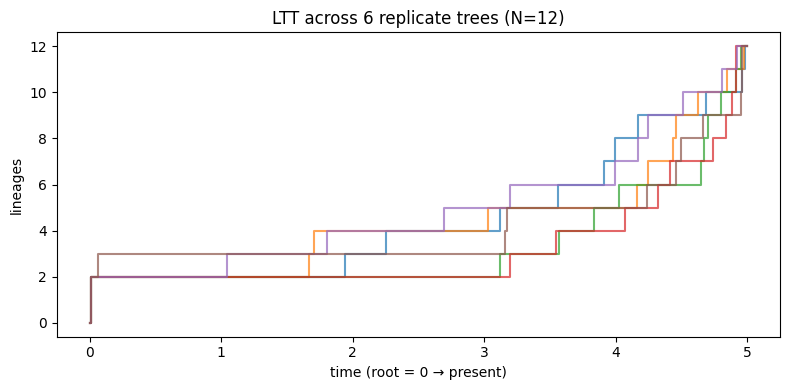

In [4]:
def ltt(tree, npts=400):
    ts = np.linspace(tree.root.time, tree.total_age, npts)
    counts = [len(tree.branches_alive_at(t)) for t in ts]
    return ts, counts

fig, ax = plt.subplots(figsize=(8, 4))
for seed in range(6):
    t2 = z.simulate_species_tree(sp, np.random.default_rng(seed))
    ts, counts = ltt(t2)
    ax.step(ts, counts, where="post", alpha=0.7)
ax.set_xlabel("time (root = 0 → present)"); ax.set_ylabel("lineages")
ax.set_title("LTT across 6 replicate trees (N=12)")
plt.tight_layout(); plt.show()

## 2. Statistical validation of the backward sampler

The internal-node **ages** should follow the reconstructed birth–death CDF. We pool ages over many trees and compare the empirical CDF to the analytic one (and run a Kolmogorov–Smirnov test).

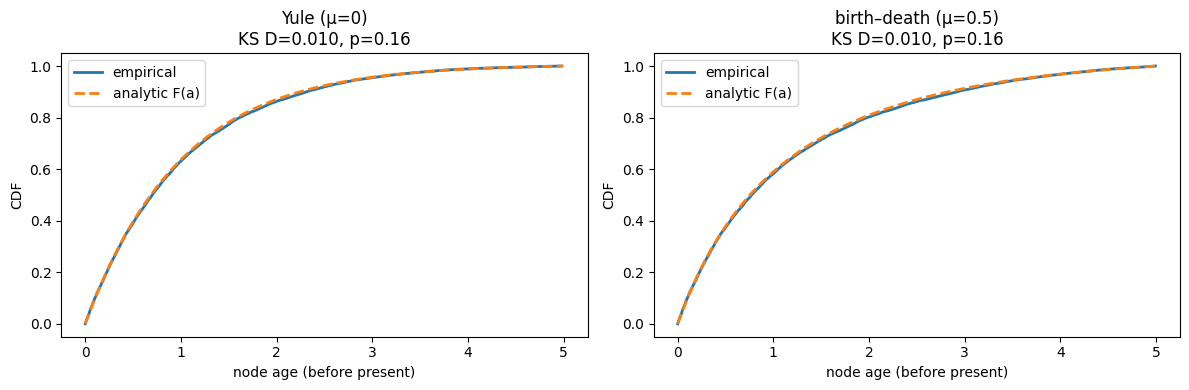

✓ sampler matches the analytic reconstructed birth–death distribution


In [5]:
from scipy import stats

def analytic_cdf(a, lam, mu, A):
    a = np.asarray(a, float)
    r = lam - mu
    if mu == 0:
        return (1 - np.exp(-lam * a)) / (1 - np.exp(-lam * A))
    g = lambda x: (1 - np.exp(-r * x)) / (lam - mu * np.exp(-r * x))
    return g(a) / g(A)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (lam, mu, label) in zip(axes, [(1.0, 0.0, "Yule (μ=0)"), (1.0, 0.5, "birth–death (μ=0.5)")]):
    A = 5.0
    model = z.SpeciesTreeModel(lam, mu, 30, age=A, age_type="stem")
    ages = []
    for s in range(400):
        tr = z.simulate_species_tree(model, np.random.default_rng(s))
        ages.extend(tr.total_age - n.time for n in tr.internal_nodes())
    ages = np.sort(np.array(ages))
    emp = np.arange(1, len(ages) + 1) / len(ages)
    ax.plot(ages, emp, lw=2, label="empirical")
    grid = np.linspace(1e-6, A, 300)
    ax.plot(grid, analytic_cdf(grid, lam, mu, A), "--", lw=2, label="analytic F(a)")
    D, p = stats.kstest(ages, lambda x: analytic_cdf(x, lam, mu, A))
    ax.set_title(f"{label}\nKS D={D:.3f}, p={p:.2f}")
    ax.set_xlabel("node age (before present)"); ax.set_ylabel("CDF"); ax.legend()
    assert p > 1e-3, (label, p)
plt.tight_layout(); plt.show()
print("✓ sampler matches the analytic reconstructed birth–death distribution")

## 3. Simulate gene families (forward D/T/L/O)

Now run the full pipeline: species tree, then gene families along it. The key output is the **phylogenetic profile matrix** (families × extant species).

In [6]:
species = z.SpeciesTreeModel(birth=1.0, death=0.2, n_tips=25, age=6.0)
rates = z.RateModel(z.EventRates(duplication=0.12, transfer=0.08, loss=0.20, origination=0.6))

result = z.Simulation(species, rates, seed=42, initial_size=40).run()

P = result.profiles
print("profile matrix (families × species):", P.matrix.shape)
print("extant species:", len(P.species))
print("gene families :", len(P.families))
print("total events  :", len(result.event_log))

from collections import Counter
counts = Counter(r.event.value for r in result.event_log)
print("events by type:", dict(counts))

profile matrix (families × species): (56, 25)
extant species: 25
gene families : 56
total events  : 843
events by type: {'O': 67, 'T': 168, 'D': 211, 'L': 397}


### The phylogenetic profile
Presence/absence of each gene family across species — this is the σ dataset the future Potts / inverse-Potts validation will consume.

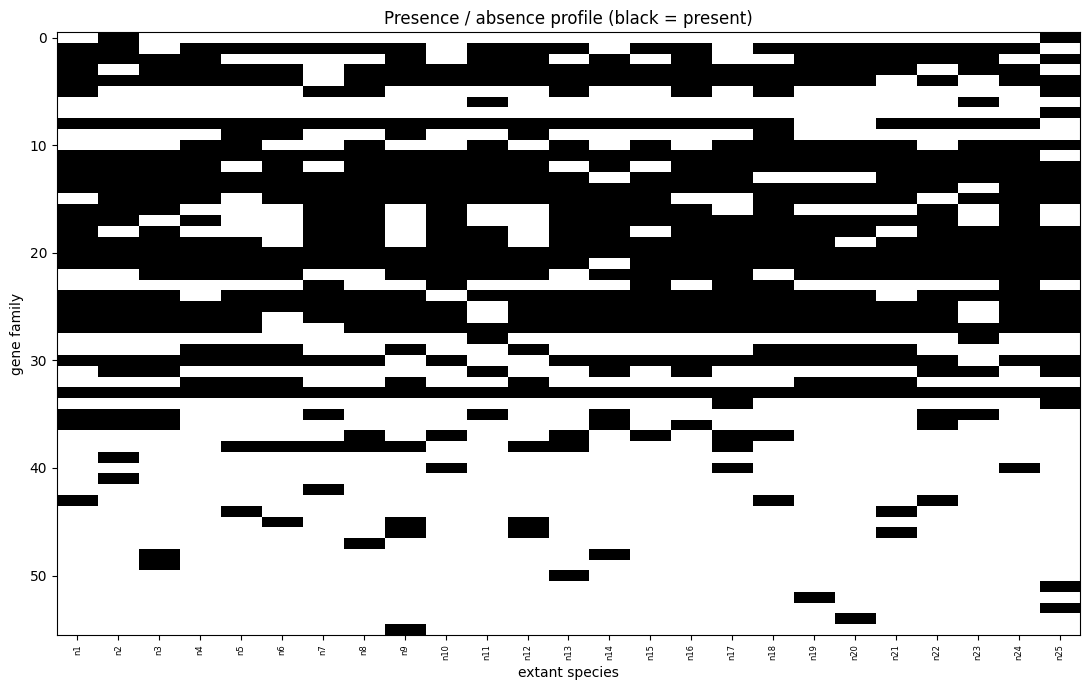

In [7]:
fig, ax = plt.subplots(figsize=(11, 7))
im = ax.imshow(P.presence(), aspect="auto", cmap="Greys", interpolation="none")
ax.set_xlabel("extant species"); ax.set_ylabel("gene family")
ax.set_xticks(range(len(P.species))); ax.set_xticklabels(P.species, rotation=90, fontsize=6)
ax.set_title("Presence / absence profile (black = present)")
plt.tight_layout(); plt.show()

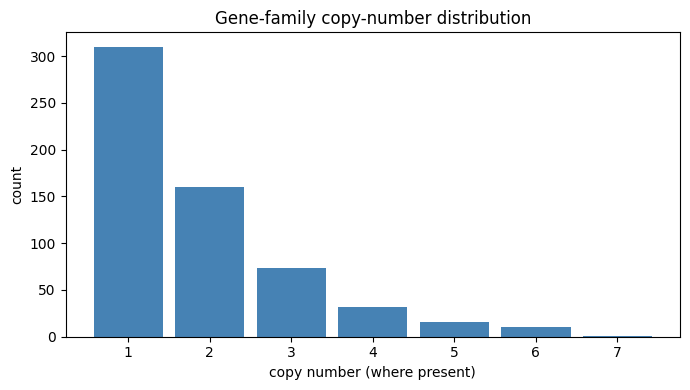

In [8]:
# copy-number distribution across all (family, species) cells that are present
vals = P.matrix[P.matrix > 0]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(vals, bins=range(1, int(vals.max()) + 2), align="left", rwidth=0.85, color="steelblue")
ax.set_xlabel("copy number (where present)"); ax.set_ylabel("count")
ax.set_title("Gene-family copy-number distribution")
plt.tight_layout(); plt.show()

## 4. Correctness checks

Two invariants that must always hold.

In [9]:
# (a) transfer time-consistency: donor and recipient co-exist at the transfer time
name2node = {n.name: n for n in result.species_tree.nodes_preorder()}
n_ok = 0
for r in result.event_log:
    if r.event is z.EventType.TRANSFER:
        d, rc = name2node[r.donor], name2node[r.recipient]
        assert r.donor != r.recipient
        for node in (d, rc):
            assert node.parent.time < r.time <= node.time + 1e-9
        n_ok += 1
print(f"✓ transfer time-consistency: {n_ok}/{n_ok} transfers valid")

# (b) reproducibility: same seed → identical results
a = z.Simulation(species, rates, seed=123, initial_size=40).run()
b = z.Simulation(species, rates, seed=123, initial_size=40).run()
assert a.species_tree.to_newick() == b.species_tree.to_newick()
assert np.array_equal(a.profiles.matrix, b.profiles.matrix)
print("✓ reproducibility: identical outputs for a fixed seed")

✓ transfer time-consistency: 168/168 transfers valid
✓ reproducibility: identical outputs for a fixed seed


## 5. Extensibility — swap the rate model, reuse everything else

The rate model consumes the whole genome, so a **genome-wise** rate model (rates independent of genome size) is a one-class change that runs through the *unchanged* simulator. This is the seam the future Potts coupling model will use.

In [10]:
class GenomeWiseRates(z.RateModel):
    """Total D/T/L rate is constant per genome (not per gene copy)."""
    def propensities(self, genome, branch, time):
        n = genome.size(); r = self.rates
        return {
            z.EventType.DUPLICATION: r.duplication if n else 0.0,
            z.EventType.TRANSFER:    r.transfer if n else 0.0,
            z.EventType.LOSS:        r.loss if n else 0.0,
            z.EventType.ORIGINATION: r.origination,
        }

gw = GenomeWiseRates(z.EventRates(duplication=0.6, transfer=0.4, loss=0.8, origination=0.6))
res_gw = z.Simulation(species, gw, seed=42, initial_size=40).run()

print("gene-wise  → families:", len(result.profiles.families),
      "| mean copies/species:", round(result.profiles.matrix.sum() / len(result.profiles.species), 1))
print("genome-wise→ families:", len(res_gw.profiles.families),
      "| mean copies/species:", round(res_gw.profiles.matrix.sum() / len(res_gw.profiles.species), 1))
print("\n✓ a new RateModel ran through the same simulator, sampler, and profile code")

gene-wise  → families: 56 | mean copies/species: 45.1
genome-wise→ families: 60 | mean copies/species: 39.0

✓ a new RateModel ran through the same simulator, sampler, and profile code


## Summary

- The **backward** species-tree sampler reproduces the analytic reconstructed
  birth–death distribution (KS test) and shows the pull of the present.
- The **forward** D/T/L/O process produces gene trees' worth of events and a
  phylogenetic profile matrix, with transfers respecting time-consistency and results
  fully reproducible from a seed.
- The **interface-first** design lets a new rate model (and, elsewhere, a new genome
  representation) drop in without touching the simulator — the seam the
  non-independence / Potts model will use next.